
У меня задача классификации. Я взял датасэт, который представляет собой записи о пациентах с диабетом в 130 больницах США с 1999 по 2008.
Моей задачей будет понять будет ли пациент повторно госпитализирован в какую-либо больницу.
Это необходимо для того, чтобы можно было изменить лечение и избежать повторной госпитализации.

В этой базе данных есть три разных варианта вывода:

- Никакой госпитализации;
- Повторная госпитализация менее чем через 30 дней (это плохой знак, возможно, лечение было неэффективным);
- Повторная госпитализация в течение более чем 30 дней (это не так хорошо, как предыдущая госпитализация, однако причиной может быть состояние пациента.



In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Импорты для классификации
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Импорты для кластеризации
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_completeness_v_measure, silhouette_score
)
from sklearn.neighbors import NearestNeighbors

1) Читаем данные

In [4]:
url = 'https://raw.githubusercontent.com/Andrew-Kop/ML_labs/main/diabetic_data.csv'
data = pd.read_csv(url, na_values=['?'], low_memory=False)
print(f"Размер датасета: {data.shape}")
print(f"Количество признаков: {data.shape[1]}")
print(f"Количество наблюдений: {data.shape[0]}")

Размер датасета: (101766, 50)
Количество признаков: 50
Количество наблюдений: 101766


Признаки имеют вид:

- `Encounter ID` — уникальный идентификатор госпитализации (можно удалить, не несёт аналитической нагрузки)
- `Patient number` — уникальный идентификатор пациента (также можно удалить, используется только для идентификации)
- `Race` — раса пациента — категориальный признак (Caucasian, Asian, African American, Hispanic, other)
- `Gender` — пол пациента — категориальный признак (male, female, unknown/invalid)
- `Age` — возраст пациента — категориальный признак, сгруппированный по 10-летним интервалам ([0,10), [10,20), …, [90,100))
- `Weight` — вес пациента в фунтах (numeric, пропусков 97%)
- `Admission type` — тип поступления (например, emergency, urgent, elective и др.) — категориальный признак
- `Discharge disposition` — исход госпитализации (discharged to home, expired и т.п.) — категориальный признак
- `Admission source` — источник направления (например, physician referral, emergency room) — категориальный признак
- `Time in hospital` — количество дней пребывания в больнице — числовой признак
- `Payer code` — страховой код (например, Blue Cross, Medicare, self-pay) — категориальный признак, 52% пропусков
- `Medical specialty` — специальность врача, принимавшего пациента (cardiology, internal medicine и др.) — категориальный признак, 53% пропусков
- `Number of lab procedures` — количество лабораторных тестов, выполненных за госпитализацию — числовой признак
- `Number of procedures` — количество процедур (кроме лабораторных) — числовой признак
- `Number of medications` — количество назначенных медикаментов — числовой признак
- `Number of outpatient visits` — число амбулаторных визитов пациента за предыдущий год — числовой признак
- `Number of emergency visits` — число обращений в отделение неотложной помощи за предыдущий год — числовой признак
- `Number of inpatient visits` — число госпитализаций за предыдущий год — числовой признак
- `Diagnosis 1`, `Diagnosis 2`, `Diagnosis 3` — основные и дополнительные диагнозы (кодированы по ICD9) — категориальные признаки
- `Number of diagnoses` — общее количество диагнозов, занесённых в систему — числовой признак
- `Glucose serum test result` — результат теста на глюкозу (">200", ">300", "normal", "none") — категориальный признак
- `A1c test result` — результат теста A1c (">8", ">7", "normal", "none") — категориальный признак
- `Change of medications` — наличие изменений в приёме медикаментов ("change" / "no change") — категориальный признак
- `Diabetes medications` — применялись ли диабетические препараты ("yes" / "no") — категориальный признак
- `24 features for medications` — информация по каждому из 24 препаратов (метформин, глимепирид и др.) — категориальные признаки ("up", "down", "steady", "no")
- `Readmitted` — целевой признак: был ли пациент повторно госпитализирован ("<30", ">30", "No")

Вот числовые признаки, которые можно взять из этого датасета:

- `time_in_hospital` — количество дней пребывания в больнице  
- `num_lab_procedures` — количество лабораторных тестов  
- `num_procedures` — количество процедур (кроме лабораторных)  
- `num_medications` — количество назначенных медикаментов  
- `number_outpatient` — число амбулаторных визитов за предыдущий год  
- `number_emergency` — число обращений в отделение неотложной помощи за предыдущий год  
- `number_inpatient` — число госпитализаций за предыдущий год  
- `number_diagnoses` — общее количество диагнозов  

Также технические признаки, мы их удалим:  
- `encounter_id`  
- `patient_nbr`  

Признаки с id (например, `admission_type_id`, `discharge_disposition_id`, `admission_source_id`) категориальные, хоть и имеют числовой тип, тоже рассматривать как числовые не будем.

2) Разбиваем на тестовую и обучающую выборки

Удаляем столбцы, которые приводят которые имеют слишком много пропусков('weight','max_glu_serum', 'A1Cresult'), слишком много уникальных значений ('diag_1', 'diag_2', 'diag_3'), а также признаки не несут нагрузки для аналитики

In [5]:
columns_to_drop = ['discharge_disposition_id', 'encounter_id',  'medical_specialty', 'patient_nbr', 'weight', 'payer_code', 'max_glu_serum', 'A1Cresult', 'diag_1', 'diag_2', 'diag_3']
data_helpful = data.drop(columns_to_drop, axis=1)
X = data_helpful.drop('readmitted', axis=1)
Y = data_helpful['readmitted']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=42)
print(f"Размер обучающих признаков: {X_train.shape}")
print(f"Размер тестовых признаков: {X_test.shape}")
print(f"Размер обучающей целевой переменной: {Y_train.shape}")
print(f"Размер тестовой целевой переменной: {Y_test.shape}")

Размер обучающих признаков: (86501, 38)
Размер тестовых признаков: (15265, 38)
Размер обучающей целевой переменной: (86501,)
Размер тестовой целевой переменной: (15265,)


3) Визуализация

In [ ]:
num_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

desc_num = data[num_cols].describe()
print("Основные статистики:\n", desc_num)

Основные статистики:
        time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count     101766.000000       101766.000000   101766.000000    101766.000000   
mean           4.395987           43.095641        1.339730        16.021844   
std            2.985108           19.674362        1.705807         8.127566   
min            1.000000            1.000000        0.000000         1.000000   
25%            2.000000           31.000000        0.000000        10.000000   
50%            4.000000           44.000000        1.000000        15.000000   
75%            6.000000           57.000000        2.000000        20.000000   
max           14.000000          132.000000        6.000000        81.000000   

       number_outpatient  number_emergency  number_inpatient  number_diagnoses  
count      101766.000000     101766.000000     101766.000000     101766.000000  
mean            0.369357          0.197836          0.635566          7.422607  
std           

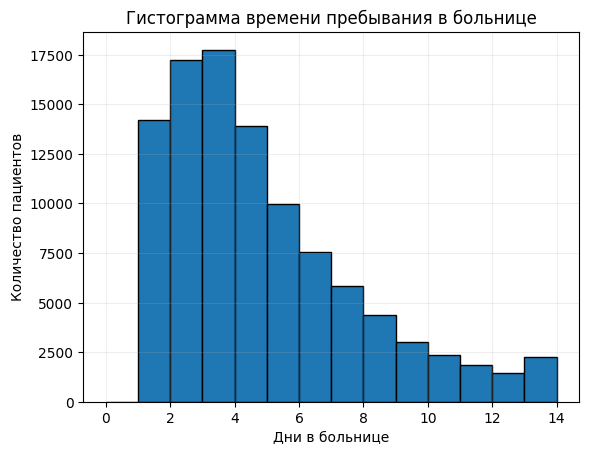

In [ ]:
plt.hist(data['time_in_hospital'], bins=range(0, 15), edgecolor='black')
plt.title('Гистограмма времени пребывания в больнице')
plt.xlabel('Дни в больнице')
plt.ylabel('Количество пациентов')
plt.grid(alpha=0.2)
plt.show()

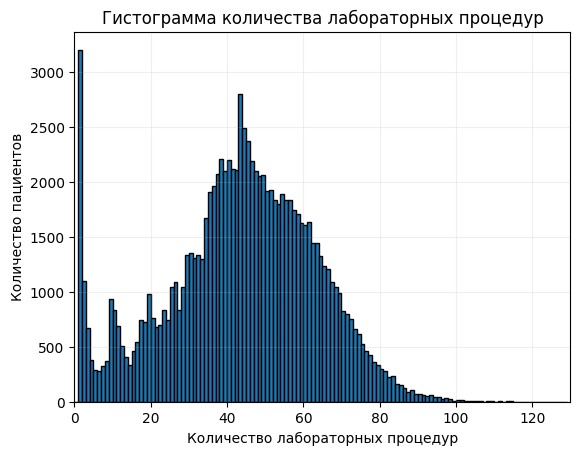

In [ ]:
plt.hist(data['num_lab_procedures'], bins=range(0, 130), edgecolor='black')
plt.title('Гистограмма количества лабораторных процедур')
plt.xlabel('Количество лабораторных процедур')
plt.ylabel('Количество пациентов')
plt.grid(alpha=0.2)
plt.xlim(0,130)
plt.show()

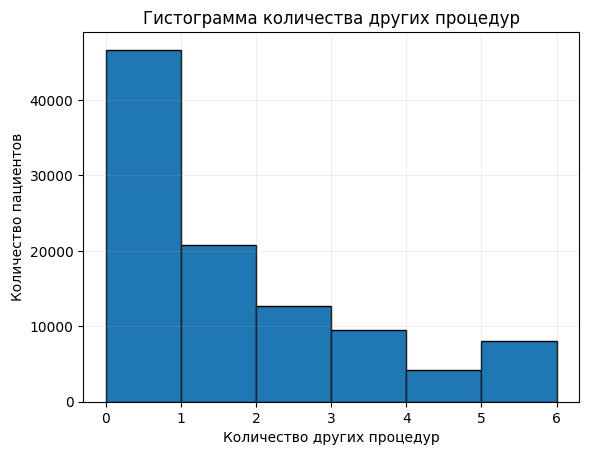

In [ ]:
plt.hist(data['num_procedures'], bins=range(0,7), edgecolor='black')
plt.title('Гистограмма количества других процедур')
plt.xlabel('Количество других процедур')
plt.ylabel('Количество пациентов')
plt.grid(alpha=0.2)
plt.show()

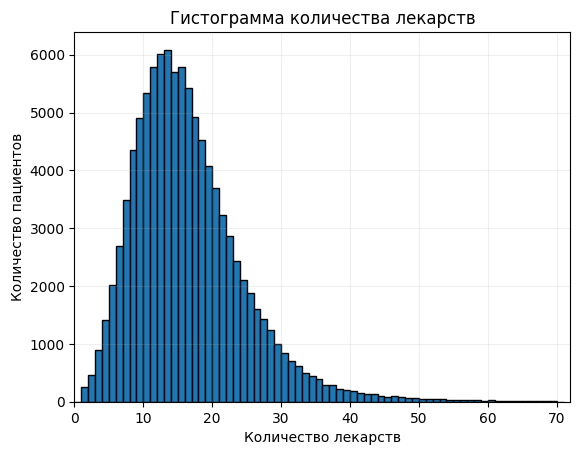

In [ ]:
plt.hist(data['num_medications'], bins=range(0,72), edgecolor='black')
plt.title('Гистограмма количества лекарств')
plt.xlabel('Количество лекарств')
plt.ylabel('Количество пациентов')
plt.grid(alpha=0.2)
plt.xlim(0, 72)
plt.show()

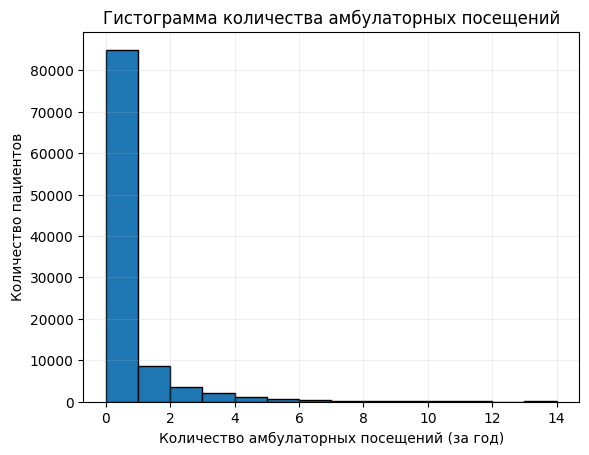

In [ ]:
plt.hist(data['number_outpatient'], bins=range(0, 15), edgecolor='black')
plt.title('Гистограмма количества амбулаторных посещений')
plt.xlabel('Количество амбулаторных посещений (за год)')
plt.ylabel('Количество пациентов')
#plt.xlim(0, 15)
plt.grid(alpha=0.2)
plt.show()

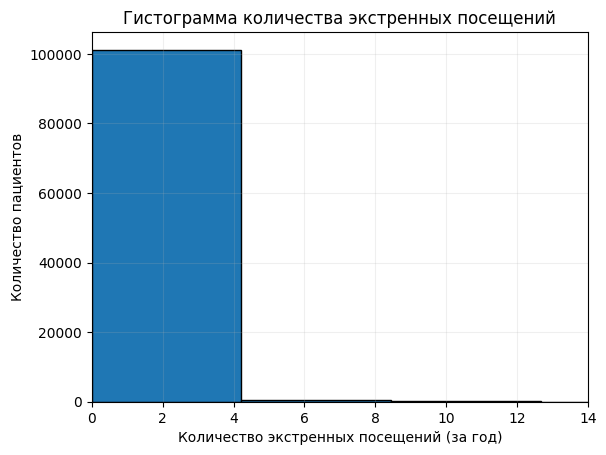

In [ ]:
plt.hist(data['number_emergency'], bins='auto', edgecolor='black')
plt.title('Гистограмма количества экстренных посещений')
plt.xlabel('Количество экстренных посещений (за год)')
plt.ylabel('Количество пациентов')
plt.xlim(0,14)
plt.grid(alpha=0.2)
plt.show()

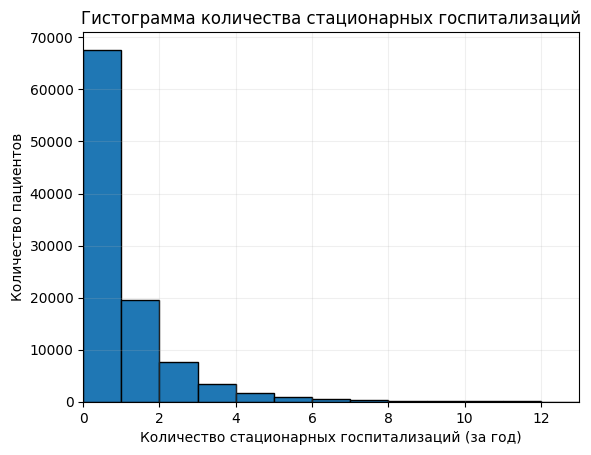

In [ ]:
plt.hist(data['number_inpatient'], bins=range(0, 15), edgecolor='black')
plt.title('Гистограмма количества стационарных госпитализаций')
plt.xlabel('Количество стационарных госпитализаций (за год)')
plt.ylabel('Количество пациентов')
plt.xlim(0,13)
plt.grid(alpha=0.2)
plt.show()

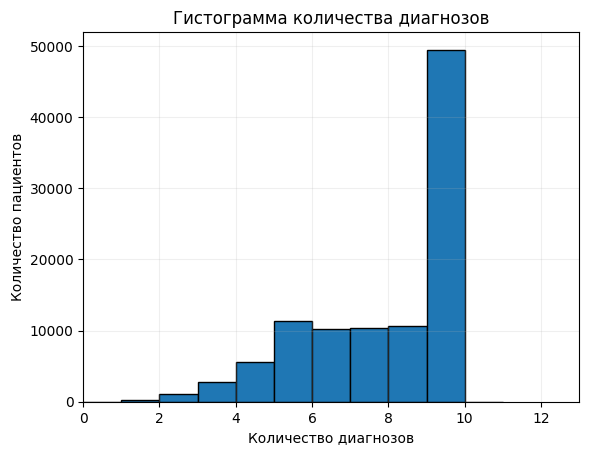

In [ ]:
plt.hist(data['number_diagnoses'], bins=range(0,12), edgecolor='black')
plt.title('Гистограмма количества диагнозов')
plt.xlabel('Количество диагнозов')
plt.ylabel('Количество пациентов')
plt.xlim(0,13)
plt.grid(alpha=0.2)
plt.show()

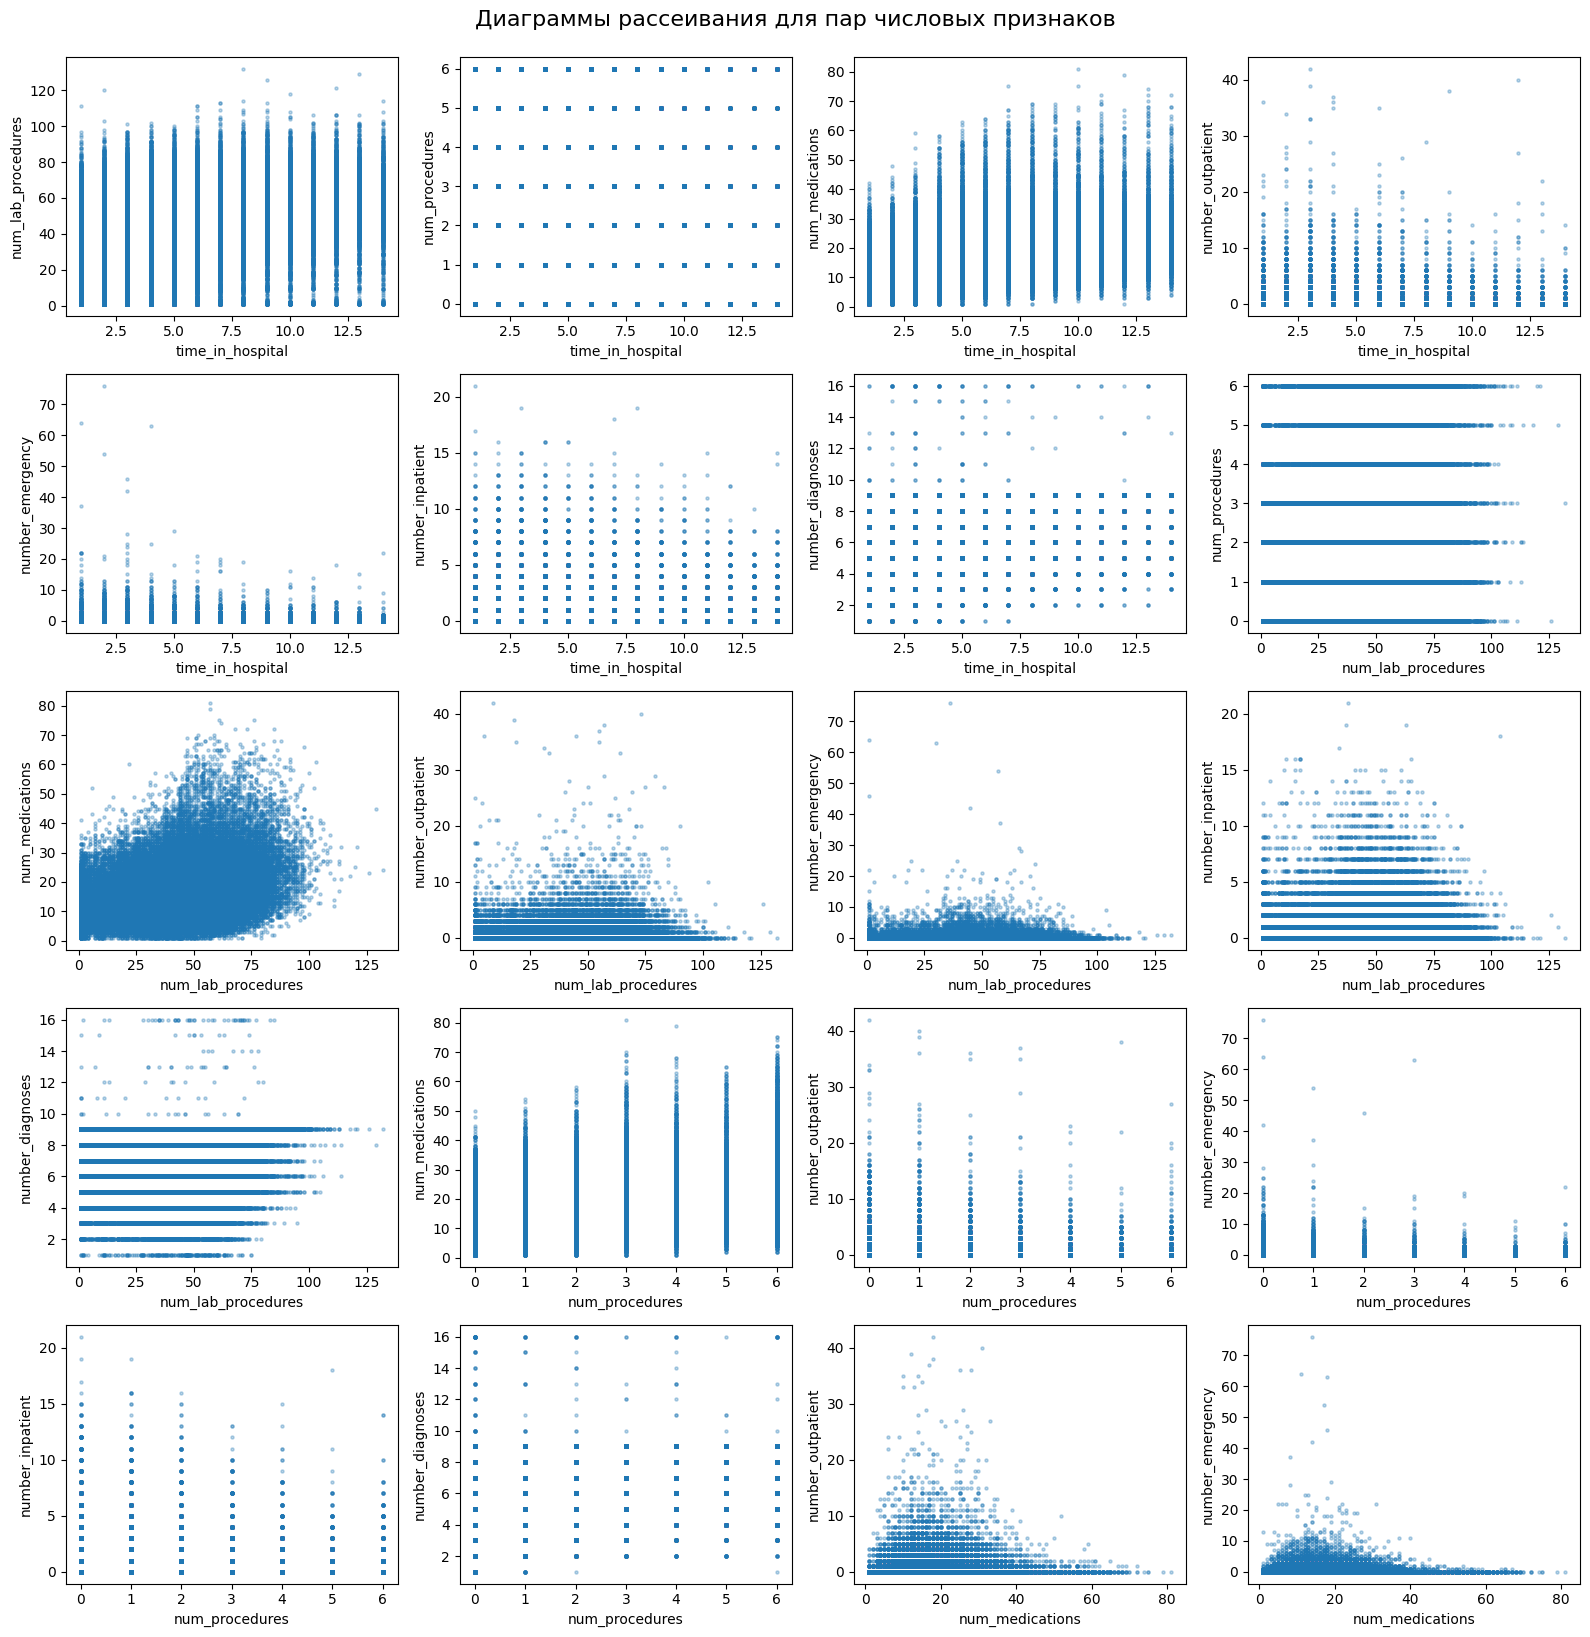

In [ ]:
num_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

import itertools

plt.figure(figsize=(16, 16))
plot_num = 1
for x_col, y_col in itertools.combinations(num_cols, 2):
    plt.subplot(5, 4, plot_num)
    plt.scatter(data[x_col], data[y_col], alpha=0.3, s=5)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plot_num += 1
    if plot_num > 20:
        break

plt.suptitle('Диаграммы рассеивания для пар числовых признаков', y=1.02, fontsize=16)
plt.show()

Построим для числовых признаков диаграммы "ящик с усами" для того, чтобы проверить, что нет больших выбросов, которые могут повлиять на работу классификатора

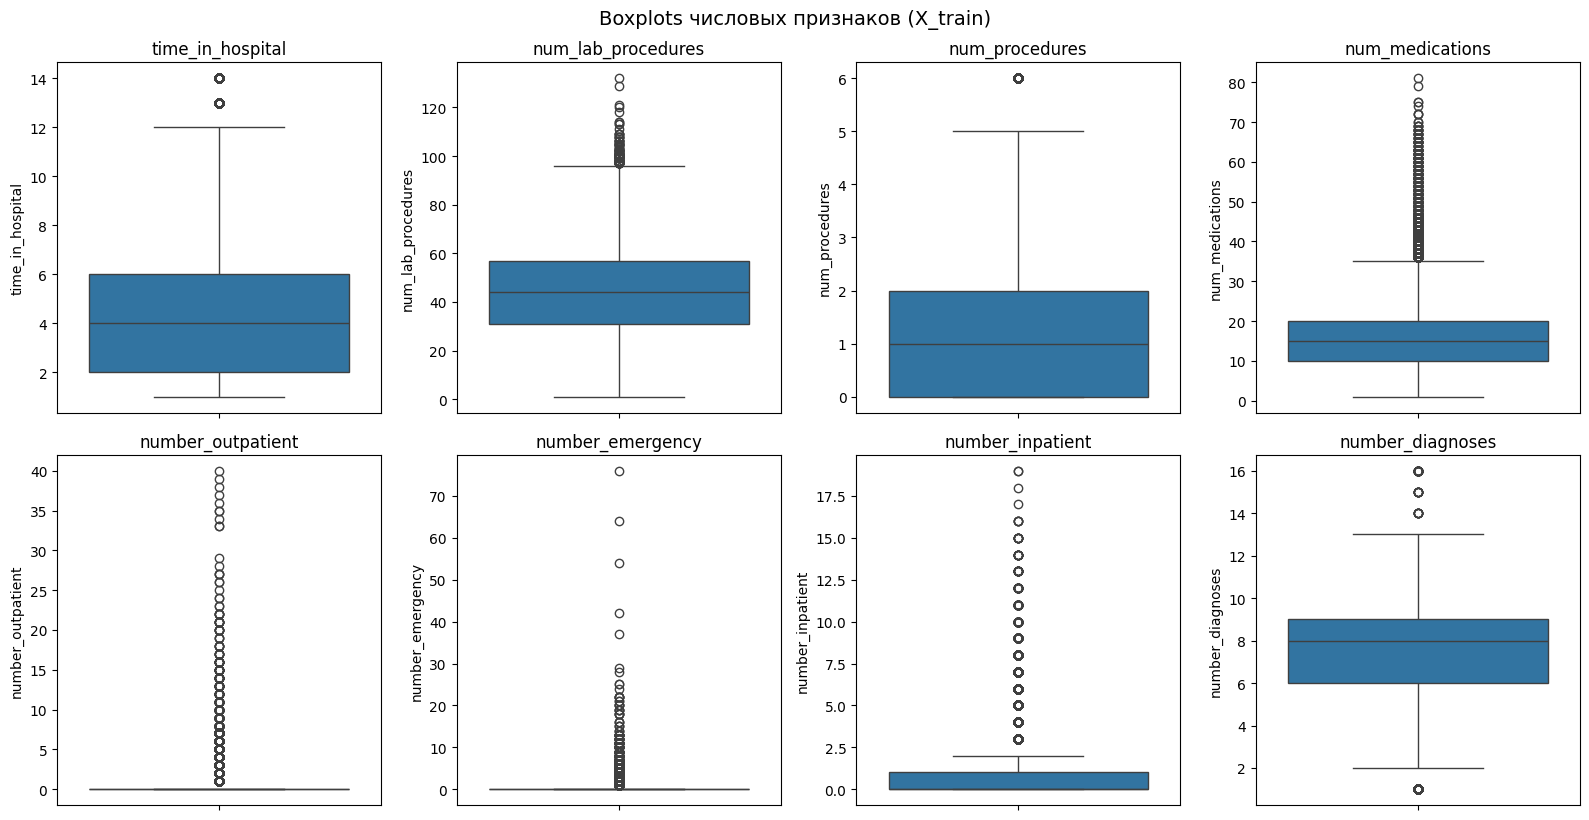

In [ ]:
plt.figure(figsize=(16, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=X_train[col])
    plt.title(col)
    plt.tight_layout()

plt.suptitle('Boxplots числовых признаков (X_train)', y=1.02, fontsize=14)
plt.show()

На основании графиков можно сделать общий вывод:

Большинство числовых признаков имеют неравномерное распределение — у большинства пациентов значения небольшие, но есть и такие, у кого показатели сильно выше остальных. Это создаёт длинные хвосты и показывает наличие выбросов.

Особенно много выбросов видно в признаках num_lab_procedures, num_medications, number_emergency и number_outpatient. Это может быть связано с тем, что у некоторых пациентов были более сложные случаи или частые обращения в больницу.

В целом данные нуждаются в дополнительной обработке — стоит нормализовать числовые признаки и убрать или ограничить выбросы, чтобы модели обучались точнее.

Построим матрицу корелляции, чтобы увидеть зависимости между числовыми признаками

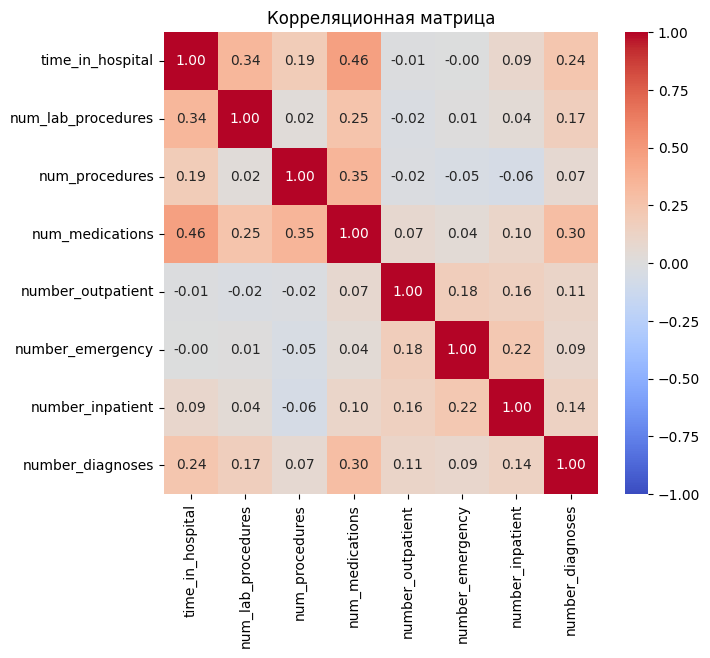

In [ ]:
corr_ff = X_train[num_cols].corr(method='spearman')
plt.figure(figsize=(7, 6))
sns.heatmap(corr_ff, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляционная матрица')
plt.show()

Длительность лечения и лекарства: Чем дольше пациент в больнице (time_in_hospital), тем больше он получает медикаментов (num_medications) (связь 0.46).

Лекарства и процедуры: Больше медикаментов также связано с большим количеством общих процедур (num_procedures) (связь 0.35).

Использование услуг: Пациенты с частыми экстренными обращениями (number_emergency) также чаще имеют стационарные госпитализации (number_inpatient) (связь 0.22).

Лабораторные тесты и время: Время в больнице также умеренно связано с количеством лабораторных тестов (num_lab_procedures) (связь 0.34).

4) Обрабатываем пропущенные значения

In [ ]:
missing = data.isnull().sum()
percent = (missing / len(data)) * 100
missing_df = pd.DataFrame({'missing': missing, 'percent': percent.round(2)})
print("Пропущенные значения в исходных данных:")
print(missing_df[missing_df['missing'] > 0])

categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    if col in X_train.columns:
        mode_value = X_train[col].mode()[0] if not X_train[col].mode().empty else 'Unknown'
        X_train[col] = X_train[col].fillna(mode_value)
        X_test[col] = X_test[col].fillna(mode_value)

numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
for col in numerical_cols:
    if col in X_train.columns and X_train[col].isna().any():
        median_value = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_value)
        X_test[col] = X_test[col].fillna(median_value)

print(f"\nПосле заполнения пропусков:")
print(f"X_train NaN: {X_train.isnull().sum().sum()}")
print(f"X_test NaN: {X_test.isnull().sum().sum()}")


Пропущенные значения в исходных данных:
                   missing  percent
race                  2273     2.23
weight               98569    96.86
payer_code           40256    39.56
medical_specialty    49949    49.08
diag_1                  21     0.02
diag_2                 358     0.35
diag_3                1423     1.40
max_glu_serum        96420    94.75
A1Cresult            84748    83.28

После заполнения пропусков:
X_train NaN: 0
X_test NaN: 0


Все признаки стали заполнены

5)Обработка категориальных данных и стандартазицация данных

In [ ]:
label_encoder = LabelEncoder()
binary_features = ['gender', 'change', 'diabetesMed']

for feature in binary_features:
    if feature in X_train.columns:
        X_train[feature] = label_encoder.fit_transform(X_train[feature])
        X_test[feature] = label_encoder.transform(X_test[feature])

age_mapping = {
    '[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3, '[40-50)': 4,
    '[50-60)': 5, '[60-70)': 6, '[70-80)': 7, '[80-90)': 8, '[90-100)': 9
}

if 'age' in X_train.columns:
    unknown_ages = set(X_train['age'].unique()) - set(age_mapping.keys())
    if unknown_ages:
        print(f"Обнаружены неизвестные значения возраста: {unknown_ages}")
        for age_val in unknown_ages:
            age_mapping[age_val] = 5

    X_train['age'] = X_train['age'].map(age_mapping)
    X_test['age'] = X_test['age'].map(age_mapping)
    X_train['age'] = X_train['age'].fillna(5)
    X_test['age'] = X_test['age'].fillna(5)

medication_features = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
                      'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
                      'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
                      'miglitol', 'troglitazone', 'tolazamide', 'examide',
                      'citoglipton', 'insulin', 'glyburide-metformin',
                      'glipizide-metformin', 'glimepiride-pioglitazone',
                      'metformin-rosiglitazone', 'metformin-pioglitazone']

medication_mapping = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

for med_feature in medication_features:
    if med_feature in X_train.columns:
        unique_values = set(X_train[med_feature].unique())
        unknown_meds = unique_values - set(medication_mapping.keys())
        if unknown_meds:
            print(f"Неизвестные значения в {med_feature}: {unknown_meds}")
            for med_val in unknown_meds:
                medication_mapping[med_val] = 0

        X_train[med_feature] = X_train[med_feature].map(medication_mapping)
        X_test[med_feature] = X_test[med_feature].map(medication_mapping)
        X_train[med_feature] = X_train[med_feature].fillna(0)
        X_test[med_feature] = X_test[med_feature].fillna(0)

categorical_features_for_ohe = ['race', 'admission_type_id',
                               'admission_source_id']

existing_categorical = [col for col in categorical_features_for_ohe if col in X_train.columns]

if existing_categorical:
    X_train = pd.get_dummies(X_train, columns=existing_categorical, drop_first=True)
    X_test = pd.get_dummies(X_test, columns=existing_categorical, drop_first=True)
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"После обработки категориальных признаков:")
print(f"Количество признаков: {X_train.shape[1]}")

После обработки категориальных признаков:
Количество признаков: 62


6)Нормализация данных

In [ ]:
num_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses'
]

existing_num_cols = [col for col in num_cols if col in X_train.columns]

if existing_num_cols:
    scaler = StandardScaler()
    X_train[existing_num_cols] = scaler.fit_transform(X_train[existing_num_cols])
    X_test[existing_num_cols] = scaler.transform(X_test[existing_num_cols])
    print(f"Нормализованы признаки: {existing_num_cols}")

print(f"\nУникальные значения в Y_train до маппинга: {sorted(Y_train.unique())}")
print(f"Уникальные значения в Y_test до маппинга: {sorted(Y_test.unique())}")

Y_train = Y_train.map({'NO': 0, 'No': 0, '>30': 1, '<30': 2})
Y_test = Y_test.map({'NO': 0, 'No': 0, '>30': 1, '<30': 2})

print(f"\nУникальные значения в Y_train после маппинга: {sorted(Y_train.unique())}")
print(f"Уникальные значения в Y_test после маппинга: {sorted(Y_test.unique())}")
print(f"Распределение Y_train после маппинга:")
print(Y_train.value_counts().sort_index())
print(f"Распределение Y_test после маппинга:")
print(Y_test.value_counts().sort_index())

if Y_train.isnull().sum() > 0 or Y_test.isnull().sum() > 0:
    most_frequent_class = Y_train.mode()[0] if not Y_train.mode().empty else 0
    Y_train = Y_train.fillna(most_frequent_class)
    Y_test = Y_test.fillna(most_frequent_class)

print(f"\nФинальные размеры данных:")
print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"X_test: {X_test.shape}, Y_test: {Y_test.shape}")

Нормализованы признаки: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Уникальные значения в Y_train до маппинга: ['<30', '>30', 'NO']
Уникальные значения в Y_test до маппинга: ['<30', '>30', 'NO']

Уникальные значения в Y_train после маппинга: [np.int64(0), np.int64(1), np.int64(2)]
Уникальные значения в Y_test после маппинга: [np.int64(0), np.int64(1), np.int64(2)]
Распределение Y_train после маппинга:
readmitted
0    46687
1    30189
2     9625
Name: count, dtype: int64
Распределение Y_test после маппинга:
readmitted
0    8177
1    5356
2    1732
Name: count, dtype: int64

Финальные размеры данных:
X_train: (86501, 62), Y_train: (86501,)
X_test: (15265, 62), Y_test: (15265,)


Нормализация нужна так как Knn построен на расстояниях и по ящикам с усами мы могли наблюдать выбросы

7)Запуск классификатора

k=2: train_acc=0.7340, test_acc=0.5306
k=3: train_acc=0.7177, test_acc=0.5106
k=4: train_acc=0.6791, test_acc=0.5282
k=5: train_acc=0.6647, test_acc=0.5298
k=6: train_acc=0.6494, test_acc=0.5372
k=7: train_acc=0.6447, test_acc=0.5364
k=8: train_acc=0.6334, test_acc=0.5418
k=9: train_acc=0.6295, test_acc=0.5450
k=10: train_acc=0.6242, test_acc=0.5471
k=11: train_acc=0.6204, test_acc=0.5477
k=12: train_acc=0.6168, test_acc=0.5513
k=13: train_acc=0.6142, test_acc=0.5501
k=14: train_acc=0.6108, test_acc=0.5509
k=15: train_acc=0.6090, test_acc=0.5539
k=16: train_acc=0.6075, test_acc=0.5538
k=17: train_acc=0.6049, test_acc=0.5546
k=18: train_acc=0.6032, test_acc=0.5568
k=19: train_acc=0.6018, test_acc=0.5592
k=20: train_acc=0.6001, test_acc=0.5598
k=21: train_acc=0.5988, test_acc=0.5581
k=22: train_acc=0.5985, test_acc=0.5603
k=23: train_acc=0.5968, test_acc=0.5594
k=24: train_acc=0.5975, test_acc=0.5589
k=25: train_acc=0.5968, test_acc=0.5603
k=26: train_acc=0.5959, test_acc=0.5625
k=27: tr

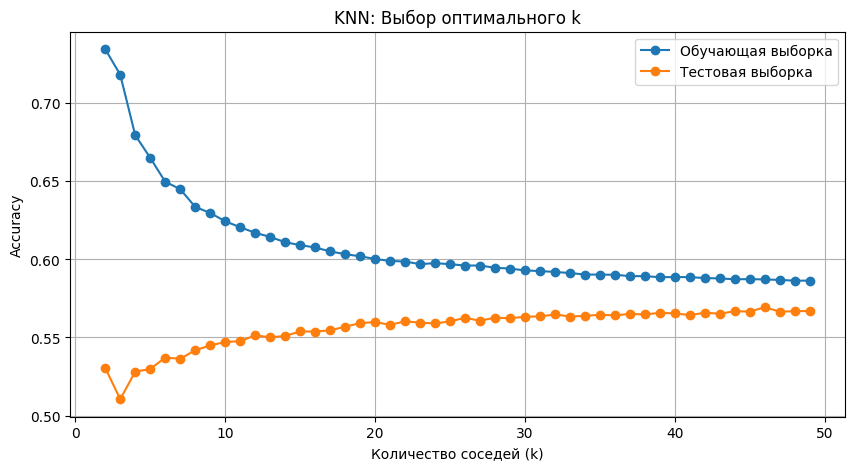

Оптимальное количество соседей: 46


In [ ]:
start_time = time.time()

k_values = range(2,50)
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train, Y_train)

    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)

    train_acc = accuracy_score(Y_train, train_pred)
    test_acc = accuracy_score(Y_test, test_pred)

    train_scores.append(train_acc)
    test_scores.append(test_acc)
    print(f"k={k}: train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")

knn_time = time.time() - start_time
print(f"KNN занял {knn_time:.2f} секунд")

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_scores, 'o-', label='Обучающая выборка')
plt.plot(k_values, test_scores, 'o-', label='Тестовая выборка')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Accuracy')
plt.title('KNN: Выбор оптимального k')
plt.legend()
plt.grid(True)
plt.show()

optimal_k = k_values[np.argmax(test_scores)]
print(f"Оптимальное количество соседей: {optimal_k}")


Почему я выбрал Knn:
Простота: Легко понять и реализовать, минимальные настройки

Локальные зависимости: В медицинских данных похожие пациенты часто имеют схожие исходы

Интерпретируемость: Можно показать "похожих соседей" как обоснование предсказания

8)Вычисление ошибок и матриц рассогласования

Accuracy на обучающей выборке: 0.5871
Accuracy на тестовой выборке: 0.5693


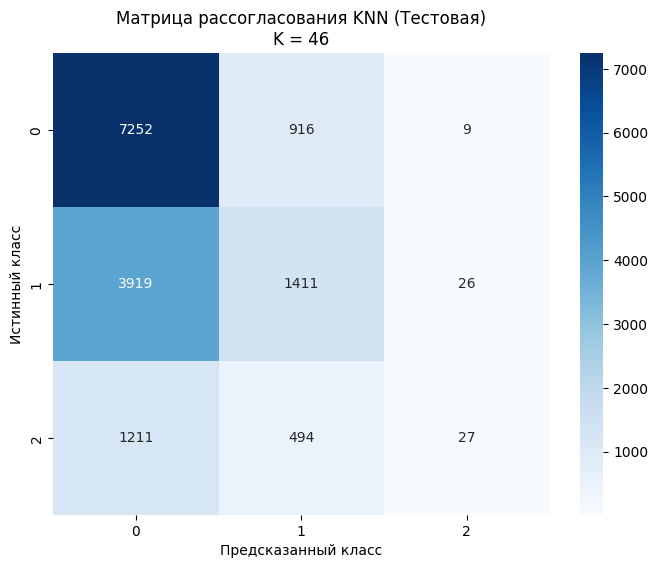


Интерпретация матрицы рассогласования:
Диагональные элементы - правильные предсказания
Внедиагональные элементы - ошибки классификации
Общая точность: 0.5693


In [ ]:
final_knn = KNeighborsClassifier(n_neighbors=optimal_k, n_jobs=-1)
final_knn.fit(X_train, Y_train)

y_train_pred = final_knn.predict(X_train)
y_test_pred = final_knn.predict(X_test)

print(f"Accuracy на обучающей выборке: {accuracy_score(Y_train, y_train_pred):.4f}")
print(f"Accuracy на тестовой выборке: {accuracy_score(Y_test, y_test_pred):.4f}")

plt.figure(figsize=(8, 6))
cm_test = confusion_matrix(Y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title(f'Матрица рассогласования KNN (Тестовая)\nK = {optimal_k}')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

print("\nИнтерпретация матрицы рассогласования:")
print("Диагональные элементы - правильные предсказания")
print("Внедиагональные элементы - ошибки классификации")
print(f"Общая точность: {accuracy_score(Y_test, y_test_pred):.4f}")

9)Сравнение с другими классификаторами

In [ ]:
# KNN
start_time = time.time()
knn = KNeighborsClassifier(n_neighbors=optimal_k, n_jobs=-1)
knn.fit(X_train, Y_train)
y_test_knn = knn.predict(X_test)
knn_time = time.time() - start_time

# Логистическая регрессия
start_time = time.time()
log_reg = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
log_reg.fit(X_train, Y_train)
y_test_log = log_reg.predict(X_test)
logreg_time = time.time() - start_time

# Решающее дерево
start_time = time.time()
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, Y_train)
y_test_tree = tree.predict(X_test)
tree_time = time.time() - start_time

# Сравнение
comparison = pd.DataFrame({
    'Method': ['KNN', 'Logistic Regression', 'Decision Tree'],
    'Test Accuracy': [
        accuracy_score(Y_test, y_test_knn),
        accuracy_score(Y_test, y_test_log),
        accuracy_score(Y_test, y_test_tree)
    ],
    'Time (sec)': [knn_time, logreg_time, tree_time]
})

print(comparison)

                Method  Test Accuracy  Time (sec)
0                  KNN       0.569276   11.739674
1  Logistic Regression       0.569997   17.258615
2        Decision Tree       0.461644    1.055491


10)Анализ несбалансированности классов

In [ ]:
print("Распределение классов в обучающей выборке:")
print(Y_train.value_counts().sort_index())
print(f"\nПроцентное распределение:")
print(Y_train.value_counts(normalize=True).sort_index() * 100)

print("\nРаспределение классов в тестовой выборке:")
print(Y_test.value_counts().sort_index())
print(f"\nПроцентное распределение:")
print(Y_test.value_counts(normalize=True).sort_index() * 100)

print("\nДетальный отчет KNN (Тестовая выборка):")
print(classification_report(Y_test, y_test_pred,
                          target_names=['No readmission', 'Readmission >30', 'Readmission <30']))

Распределение классов в обучающей выборке:
readmitted
0    46687
1    30189
2     9625
Name: count, dtype: int64

Процентное распределение:
readmitted
0    53.972786
1    34.900175
2    11.127039
Name: proportion, dtype: float64

Распределение классов в тестовой выборке:
readmitted
0    8177
1    5356
2    1732
Name: count, dtype: int64

Процентное распределение:
readmitted
0    53.566983
1    35.086800
2    11.346217
Name: proportion, dtype: float64

Детальный отчет KNN (Тестовая выборка):
                 precision    recall  f1-score   support

 No readmission       0.59      0.89      0.71      8177
Readmission >30       0.50      0.26      0.35      5356
Readmission <30       0.44      0.02      0.03      1732

       accuracy                           0.57     15265
      macro avg       0.51      0.39      0.36     15265
   weighted avg       0.54      0.57      0.50     15265



Общие выводы:
Мы попробовали предсказать, когда диабетики снова попадут в больницу, используя три разных метода.

Логистическая Регрессия и KNN (ближайшие соседи) сработали лучше всего, угадав правильно примерно 57% случаев.

Дерево Решений показало самый слабый результат — всего 46%.

Главный вывод: Точность 57% — это достаточно низко. Это означает, что модели с трудом предсказывают значения. Как видно из матрицы рассогласования это следует из того, что сложно определить будет ли госпитализирован после месяца от последнего приёма или не будет госпитазирован вовсе


Размер исходных данных для кластеризации: (101766, 39)
Размер подвыборки для кластеризации: (40706, 39) (40% данных)

1. Заполнение пропущенных значений...
2. Кодирование бинарных признаков...
3. Обработка признака 'age'...
4. Обработка признаков лекарств...
5. One-hot encoding категориальных признаков...
6. Масштабирование числовых признаков...

Размер данных для кластеризации: (40706, 58)
Размер целевой переменной: (40706,)
Распределение классов в целевой переменной: [21933 14209  4564]
Уникальные значения: [0 1 2]

--- Применение PCA для визуализации ---
Объясненная дисперсия PCA: [0.19226441 0.14847872]
Суммарная объясненная дисперсия: 0.341

--- Подбор оптимального k для KMeans ---
  Тестируем k=2...
  Тестируем k=3...
  Тестируем k=4...
  Тестируем k=5...
  Тестируем k=6...
  Тестируем k=7...
  Тестируем k=8...
  Тестируем k=9...
  Тестируем k=10...
Оптимальное k по silhouette: 2
Обучение KMeans с оптимальным k...

--- Подбор параметров для DBSCAN ---
Выбранный eps: 2.401
Обучени

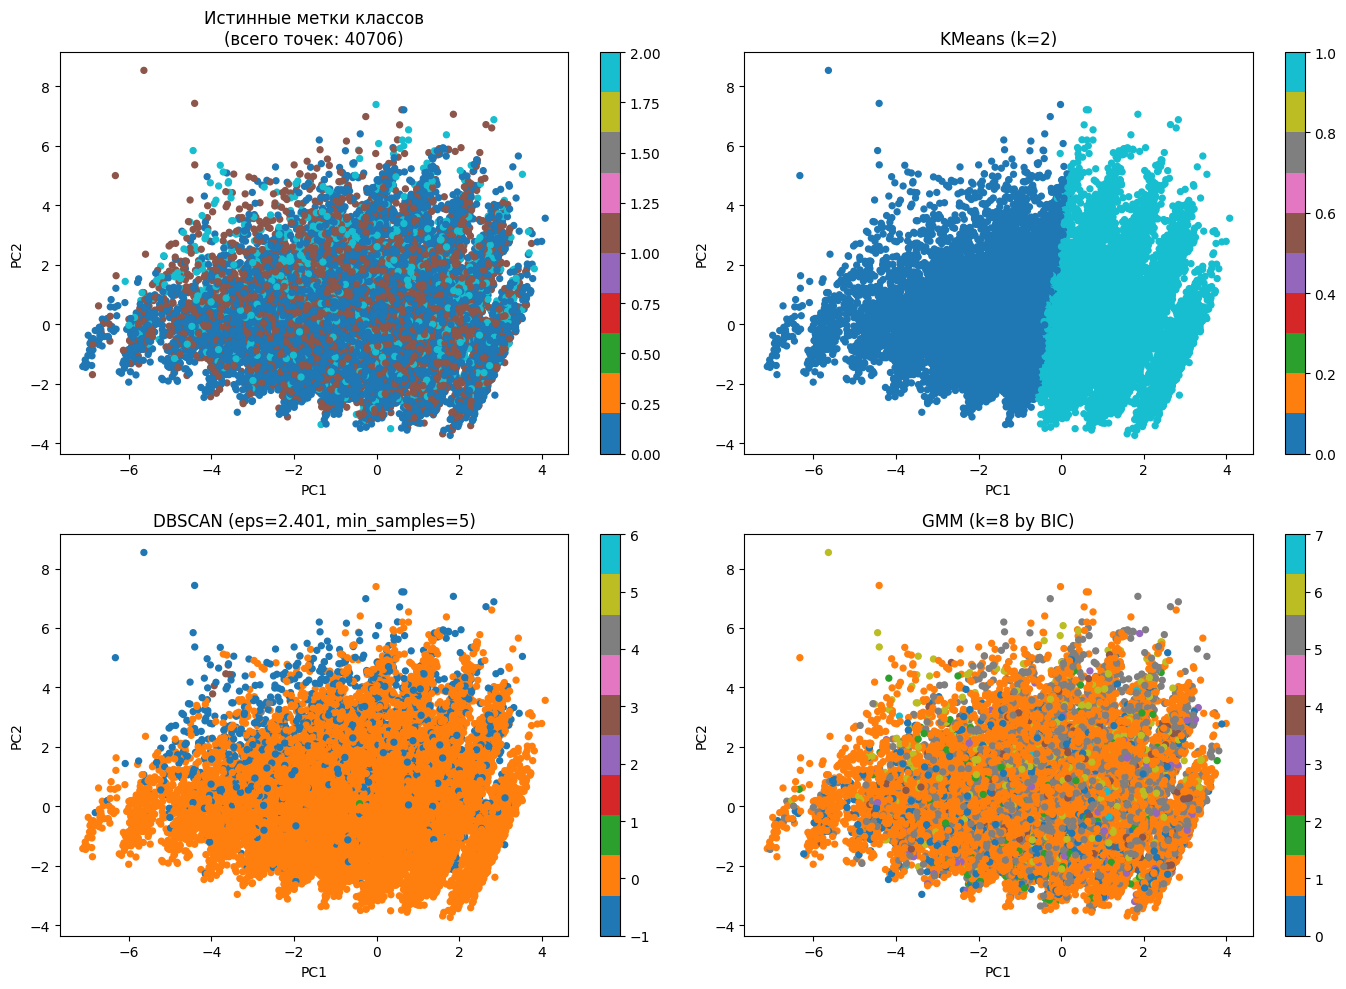

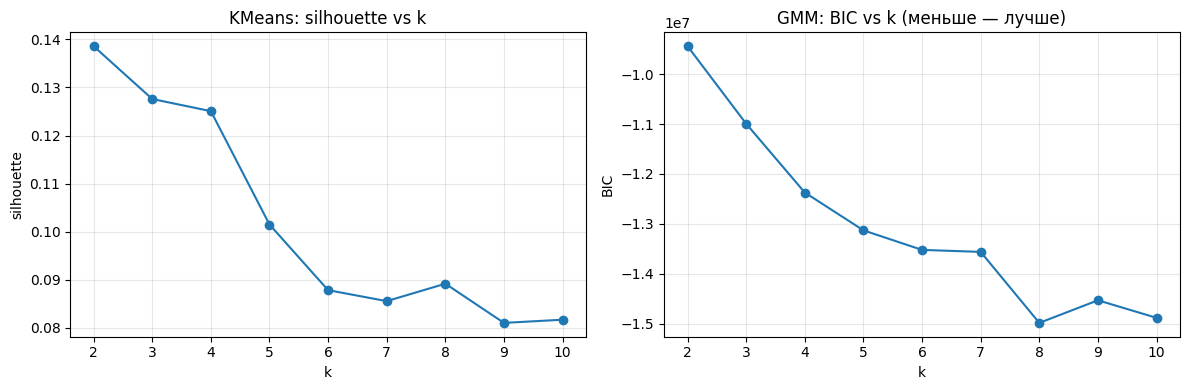


--- Анализ распределения кластеров ---

KMeans:
  Кластер 0: 15264 точек (37.5%)
  Кластер 1: 25442 точек (62.5%)

DBSCAN:
  Шум (-1): 2278 точек (5.6%)
  Кластер 0: 38403 точек (94.3%)
  Кластер 1: 4 точек (0.0%)
  Кластер 2: 5 точек (0.0%)
  Кластер 3: 5 точек (0.0%)
  Кластер 4: 2 точек (0.0%)
  Кластер 5: 5 точек (0.0%)
  Кластер 6: 4 точек (0.0%)

GMM:
  Кластер 0: 2386 точек (5.9%)
  Кластер 1: 24194 точек (59.4%)
  Кластер 2: 643 точек (1.6%)
  Кластер 3: 466 точек (1.1%)
  Кластер 4: 832 точек (2.0%)
  Кластер 5: 10584 точек (26.0%)
  Кластер 6: 1514 точек (3.7%)
  Кластер 7: 87 точек (0.2%)

--- Соответствие кластеров истинным классам (KMeans) ---
Таблица сопряженности (строки - кластеры, столбцы - истинные классы):
true_label      0     1     2
cluster                      
0            8755  5031  1478
1           13178  9178  3086

Наиболее представленные классы в каждом кластере:
  Кластер 0: класс 0 (57.4% точек кластера)
  Кластер 1: класс 0 (51.8% точек кластера)


In [13]:
url = 'https://raw.githubusercontent.com/Andrew-Kop/ML_labs/main/diabetic_data.csv'
data = pd.read_csv(url, na_values=['?'], low_memory=False)

columns_to_drop = ['discharge_disposition_id', 'encounter_id', 'medical_specialty',
                   'patient_nbr', 'weight', 'payer_code', 'max_glu_serum',
                   'A1Cresult', 'diag_1', 'diag_2', 'diag_3']
data_helpful = data.drop(columns_to_drop, axis=1)

print(f"Размер исходных данных для кластеризации: {data_helpful.shape}")

sample_fraction = 0.40  # взял 40% данных, так как на всех данных у меня компьютер считал полдня и так и не закончил
data_sample = data_helpful.sample(frac=sample_fraction, random_state=42)
print(f"Размер подвыборки для кластеризации: {data_sample.shape} ({sample_fraction*100:.0f}% данных)")

X_all = data_sample.drop('readmitted', axis=1)
y_original = data_sample['readmitted']
age_mapping = {
    '[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3, '[40-50)': 4,
    '[50-60)': 5, '[60-70)': 6, '[70-80)': 7, '[80-90)': 8, '[90-100)': 9
}

medication_mapping = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

medication_features = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
                      'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
                      'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
                      'miglitol', 'troglitazone', 'tolazamide', 'examide',
                      'citoglipton', 'insulin', 'glyburide-metformin',
                      'glipizide-metformin', 'glimepiride-pioglitazone',
                      'metformin-rosiglitazone', 'metformin-pioglitazone']

categorical_features_for_ohe = ['race', 'admission_type_id', 'admission_source_id']
num_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses'
]

X_cluster = X_all.copy()
print("\n1. Заполнение пропущенных значений...")
categorical_cols = X_cluster.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    if col in X_cluster.columns:
        mode_value = X_cluster[col].mode()[0] if not X_cluster[col].mode().empty else 'Unknown'
        X_cluster[col] = X_cluster[col].fillna(mode_value)

numerical_cols = X_cluster.select_dtypes(include=[np.number]).columns.tolist()
for col in numerical_cols:
    if col in X_cluster.columns and X_cluster[col].isna().any():
        median_value = X_cluster[col].median()
        X_cluster[col] = X_cluster[col].fillna(median_value)

print("2. Кодирование бинарных признаков...")
label_encoder = LabelEncoder()
binary_features = ['gender', 'change', 'diabetesMed']

for feature in binary_features:
    if feature in X_cluster.columns:
        X_cluster[feature] = label_encoder.fit_transform(X_cluster[feature])


print("3. Обработка признака 'age'...")
if 'age' in X_cluster.columns:
    unknown_ages = set(X_cluster['age'].unique()) - set(age_mapping.keys())
    if unknown_ages:
        for age_val in unknown_ages:
            age_mapping[age_val] = 5

    X_cluster['age'] = X_cluster['age'].map(age_mapping)
    X_cluster['age'] = X_cluster['age'].fillna(5)

print("4. Обработка признаков лекарств...")
for med_feature in medication_features:
    if med_feature in X_cluster.columns:
        unique_values = set(X_cluster[med_feature].unique())
        unknown_meds = unique_values - set(medication_mapping.keys())
        if unknown_meds:
            for med_val in unknown_meds:
                medication_mapping[med_val] = 0

        X_cluster[med_feature] = X_cluster[med_feature].map(medication_mapping)
        X_cluster[med_feature] = X_cluster[med_feature].fillna(0)


print("5. One-hot encoding категориальных признаков...")
existing_categorical = [col for col in categorical_features_for_ohe if col in X_cluster.columns]
if existing_categorical:
    X_cluster = pd.get_dummies(X_cluster, columns=existing_categorical, drop_first=True)


print("6. Масштабирование числовых признаков...")
existing_num_cols = [col for col in num_cols if col in X_cluster.columns]
if existing_num_cols:
    scaler = StandardScaler()
    X_cluster[existing_num_cols] = scaler.fit_transform(X_cluster[existing_num_cols])

X_arr = X_cluster.to_numpy()
y_original_mapped = y_original.map({'NO': 0, 'No': 0, '>30': 1, '<30': 2}).fillna(0).astype(int)
y_arr = y_original_mapped.to_numpy()

print(f"\nРазмер данных для кластеризации: {X_arr.shape}")
print(f"Размер целевой переменной: {y_arr.shape}")
print(f"Распределение классов в целевой переменной: {np.bincount(y_arr)}")
print(f"Уникальные значения: {np.unique(y_arr)}")


def safe_silhouette(X, labels):

    uniq = np.unique(labels)
    if len(uniq) < 2:
        return np.nan
    try:
        return silhouette_score(X, labels)
    except Exception:
        return np.nan

def choose_k_by_silhouette(X, k_range=range(2, 11), random_state=42):
    best_k, best_s = None, -np.inf
    scores = {}
    for k in k_range:
        print(f"  Тестируем k={k}...")
        km = KMeans(n_clusters=k, n_init="auto", random_state=random_state)
        labels = km.fit_predict(X)
        s = safe_silhouette(X, labels)
        scores[k] = s
        if np.isfinite(s) and s > best_s:
            best_s, best_k = s, k
    return best_k, scores

def choose_dbscan_eps_knn(X, k=5, q=0.90):
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X)
    dists, _ = nn.kneighbors(X)
    kth = np.sort(dists[:, -1])
    eps = float(np.quantile(kth, q))
    return eps

def evaluate_vs_true(y_true, y_pred):
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    h, c, v = homogeneity_completeness_v_measure(y_true, y_pred)
    return {"ARI": ari, "NMI": nmi, "homogeneity": h, "completeness": c, "v_measure": v}

# PCA для визуализации (2 компоненты)
print("\n--- Применение PCA для визуализации ---")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_arr)
print(f"Объясненная дисперсия PCA: {pca.explained_variance_ratio_}")
print(f"Суммарная объясненная дисперсия: {sum(pca.explained_variance_ratio_):.3f}")

# ----------  KMeans  ----------
print("\n--- Подбор оптимального k для KMeans ---")
start_time = time.time()
best_k, k_scores = choose_k_by_silhouette(X_arr, k_range=range(2, 11), random_state=42)
print(f"Оптимальное k по silhouette: {best_k}")

print("Обучение KMeans с оптимальным k...")
kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=42)
km_labels = kmeans.fit_predict(X_arr)

# ---------- DBSCAN ----------
print("\n--- Подбор параметров для DBSCAN ---")
eps = choose_dbscan_eps_knn(X_arr, k=5, q=0.90)
print(f"Выбранный eps: {eps:.3f}")
print("Обучение DBSCAN...")
dbscan = DBSCAN(eps=eps, min_samples=5, n_jobs=-1)
db_labels = dbscan.fit_predict(X_arr)
print(f"DBSCAN нашел {len(np.unique(db_labels))} кластеров (+ шум)")
print(f"Количество точек шума: {np.sum(db_labels == -1)}")

# ---------- Gaussian Mixture ----------
print("\n--- Подбор числа компонент для Gaussian Mixture ---")
bic_best = (None, np.inf)
bic_curve = {}
for k in range(2, 11):
    print(f"  Тестируем k={k}...")
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    gmm.fit(X_arr)
    bic = gmm.bic(X_arr)
    bic_curve[k] = bic
    if bic < bic_best[1]:
        bic_best = (k, bic)
print(f"Оптимальное число компонент по BIC: {bic_best[0]}")

print("Обучение GMM...")
gmm = GaussianMixture(n_components=bic_best[0], covariance_type="full", random_state=42)
gmm_labels = gmm.fit_predict(X_arr)

# ---------- Оценка----------
print("\n--- Оценка результатов кластеризации ---")
results = []


results.append(("KMeans", best_k, safe_silhouette(X_arr, km_labels), evaluate_vs_true(y_arr, km_labels)))
results.append(("DBSCAN", f"eps={eps:.3f}", safe_silhouette(X_arr, db_labels), evaluate_vs_true(y_arr, db_labels)))
results.append(("GMM", bic_best[0], safe_silhouette(X_arr, gmm_labels), evaluate_vs_true(y_arr, gmm_labels)))

summary = []
for name, param, sil, ext in results:
    row = {"algo": name, "param": param, "silhouette": sil}
    row.update(ext)
    summary.append(row)

summary_df = pd.DataFrame(summary).sort_values(["ARI", "NMI"], ascending=False)
print("\nСравнение методов кластеризации:")
print(summary_df)

# ---------- Визуализация в PCA ----------
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
scatter1 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_arr, s=18, cmap="tab10")
plt.colorbar(scatter1)
plt.title(f"Истинные метки классов\n(всего точек: {len(X_pca)})")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(2, 2, 2)
scatter2 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, s=18, cmap="tab10")
plt.colorbar(scatter2)
plt.title(f"KMeans (k={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(2, 2, 3)
scatter3 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, s=18, cmap="tab10")
plt.colorbar(scatter3)
plt.title(f"DBSCAN (eps={eps:.3f}, min_samples=5)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(2, 2, 4)
scatter4 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, s=18, cmap="tab10")
plt.colorbar(scatter4)
plt.title(f"GMM (k={bic_best[0]} by BIC)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(list(k_scores.keys()), list(k_scores.values()), marker="o")
plt.title("KMeans: silhouette vs k")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(list(bic_curve.keys()), list(bic_curve.values()), marker="o")
plt.title("GMM: BIC vs k (меньше — лучше)")
plt.xlabel("k")
plt.ylabel("BIC")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- Анализ распределения кластеров ---")
for name, labels in [("KMeans", km_labels), ("DBSCAN", db_labels), ("GMM", gmm_labels)]:
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{name}:")
    for u, c in zip(unique, counts):
        if u == -1:
            print(f"  Шум (-1): {c} точек ({c/len(labels)*100:.1f}%)")
        else:
            print(f"  Кластер {u}: {c} точек ({c/len(labels)*100:.1f}%)")


print("\n--- Соответствие кластеров истинным классам (KMeans) ---")
cluster_df = pd.DataFrame({
    'true_label': y_arr,
    'cluster': km_labels
})
contingency_table = pd.crosstab(cluster_df['cluster'], cluster_df['true_label'])
print("Таблица сопряженности (строки - кластеры, столбцы - истинные классы):")
print(contingency_table)


print("\nНаиболее представленные классы в каждом кластере:")
for cluster in contingency_table.index:
    most_common_class = contingency_table.loc[cluster].idxmax()
    percentage = (contingency_table.loc[cluster, most_common_class] / contingency_table.loc[cluster].sum()) * 100
    print(f"  Кластер {cluster}: класс {most_common_class} ({percentage:.1f}% точек кластера)")


На основе проведённого анализа кластеризации данных можно сделать следующие выводы:

Качество кластеризации оказалось в целом низким. Наилучшие результаты по Silhouette Score (0.1386) показал метод KMeans при k=2, что подтверждается графиком silhouette vs k. GMM продемонстрировал отрицательный silhouette (-0.0258), что указывает на плохое разделение кластеров, а DBSCAN — очень низкое качество (0.0281) с обнаружением 5.6% шумовых точек.

Оптимальное число кластеров различается между методами: для KMeans оно составило 2, для GMM — 8 компонент (по минимуму BIC), а DBSCAN автоматически выделил 8 кластеров, из которых 94.3% точек оказались в одном кластере, что говорит о непригодности DBSCAN для данной структуры данных.

Согласованность кластеров с истинными классами крайне слабая: все метрики (ARI, NMI, homogeneity, completeness) близки к нулю или отрицательны. KMeans, несмотря на лучший silhouette, также плохо соответствует исходным классам — в обоих его кластерах преобладает класс 0 (57.4% и 51.8%).

Распределение точек по кластерам неравномерно: KMeans разделил данные в пропорции 37.5%/62.5%, GMM выделил один доминирующий кластер (59.4%), а DBSCAN показал один крупный кластер и несколько микро-кластеров по 2–5 точек.

PCA выявил низкую объяснённую дисперсию (34.1% на двух компонентах), что свидетельствует о высокой размерности и сложной структуре данных, плохо поддающейся кластеризации.